In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc

In [2]:
df = pd.read_csv('customer_churn_dataset_ML.csv')

In [3]:
print("Rows, Columns:", df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe())


Rows, Columns: (64374, 12)
   CustomerID  Age  Gender  Tenure  Usage Frequency  Support Calls  \
0           1   22  Female      25               14              4   
1           2   41  Female      28               28              7   
2           3   47    Male      27               10              2   
3           4   35    Male       9               12              5   
4           5   53  Female      58               24              9   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0             27             Basic         Monthly          598   
1             13          Standard         Monthly          584   
2             29           Premium          Annual          757   
3             17           Premium       Quarterly          232   
4              2          Standard          Annual          533   

   Last Interaction  Churn  
0                 9      1  
1                20      0  
2                21      0  
3                18      0  
4   

In [4]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [5]:
print(df.columns.tolist())

['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']


In [6]:
cat_cols = ['Gender','Subscription Type','Contract Length']
for col in cat_cols + ['Churn']:
    print(f"{col} unique values:", df[col].unique())

Gender unique values: ['Female' 'Male']
Subscription Type unique values: ['Basic' 'Standard' 'Premium']
Contract Length unique values: ['Monthly' 'Annual' 'Quarterly']
Churn unique values: [1 0]


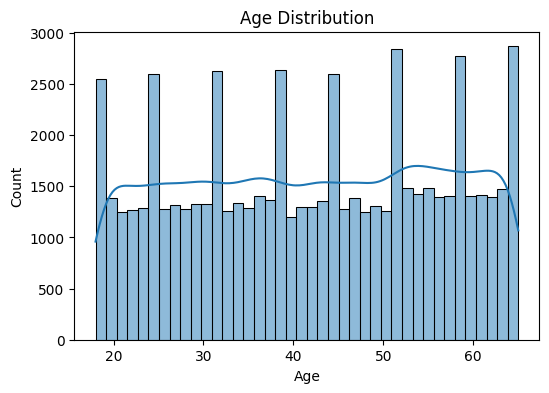

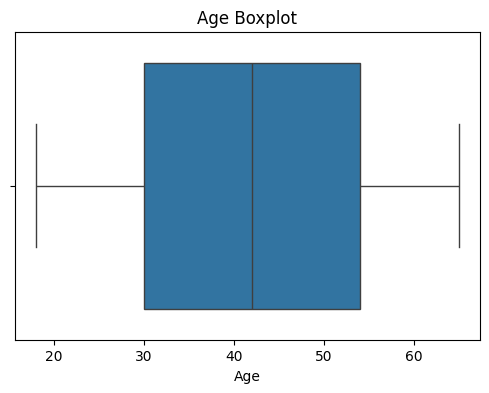

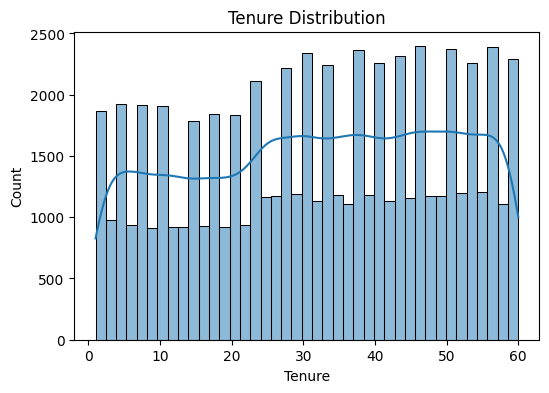

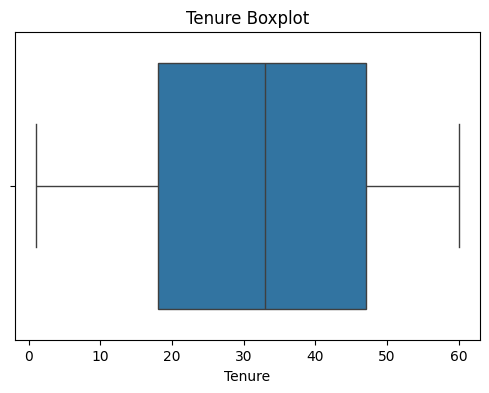

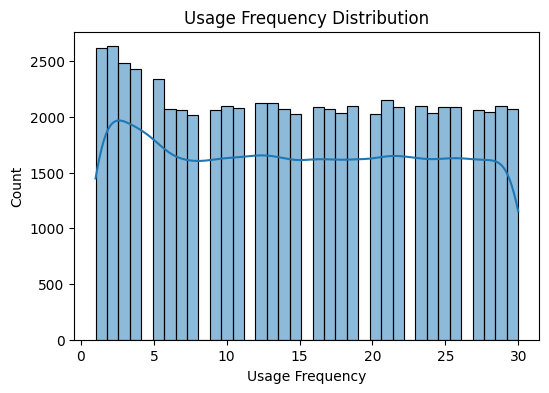

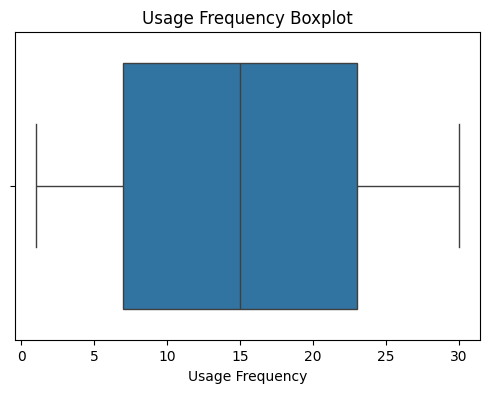

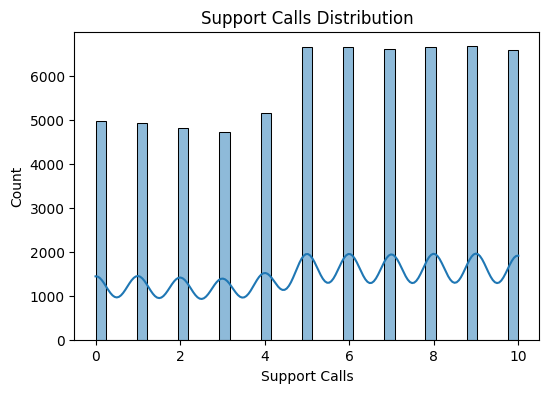

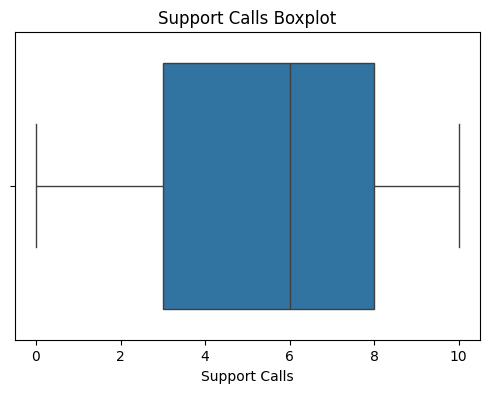

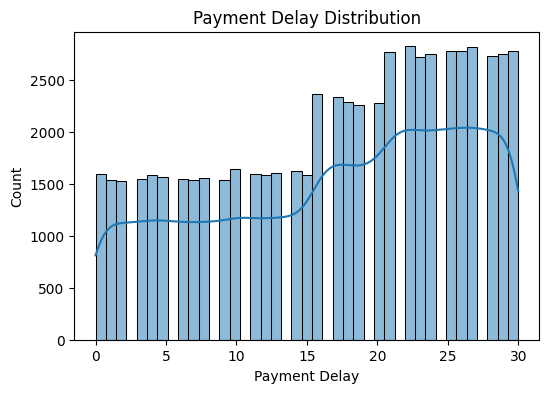

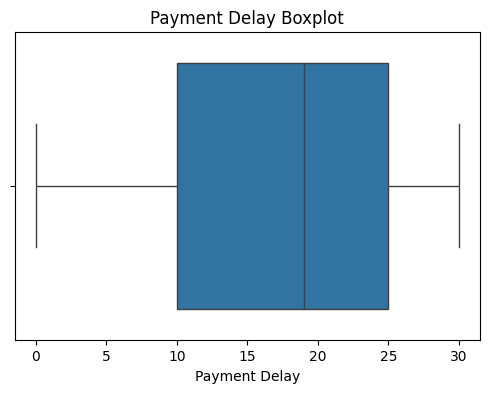

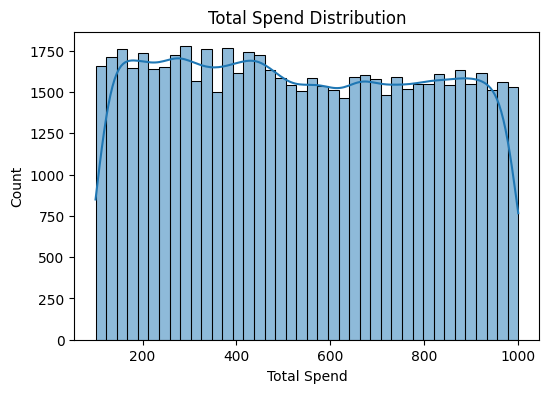

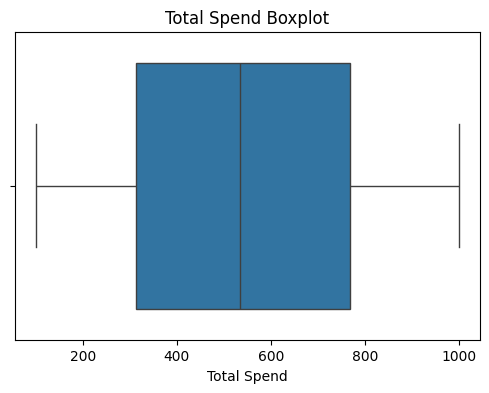

In [8]:
#Graph Analysis
#(A)Univariate Analysis
# Numerical Features
num_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'{col} Distribution')
    plt.show()

    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'{col} Boxplot')
    plt.show()

In [9]:
# Catogrial features count
# Gender Count 
print(df['Gender'].value_counts())
# Subscription tyoe 
print(df['Subscription Type'].value_counts())
# Contract Length
print(df['Contract Length'].value_counts())
#Churn
print(df['Churn'].value_counts())

Gender
Female    34353
Male      30021
Name: count, dtype: int64
Subscription Type
Standard    21502
Basic       21451
Premium     21421
Name: count, dtype: int64
Contract Length
Monthly      22130
Annual       21410
Quarterly    20834
Name: count, dtype: int64
Churn
0    33881
1    30493
Name: count, dtype: int64


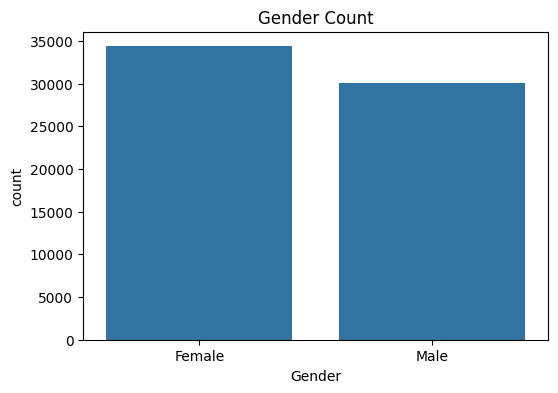

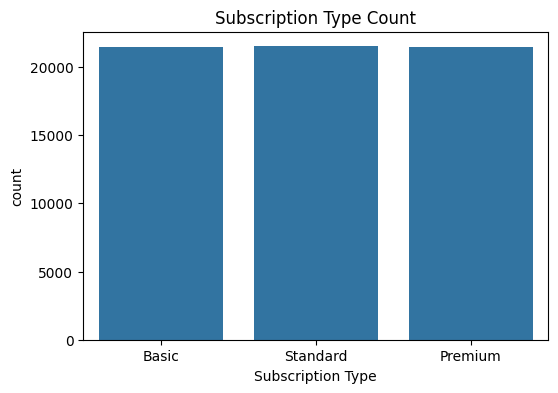

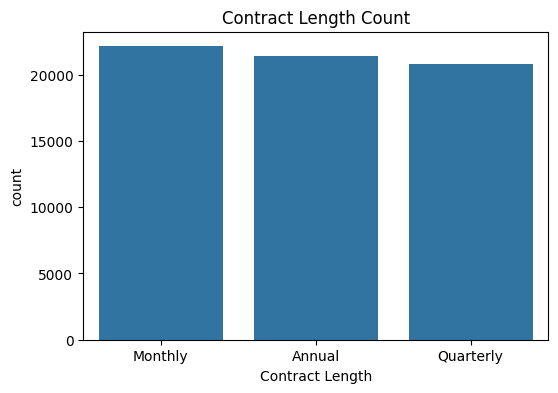

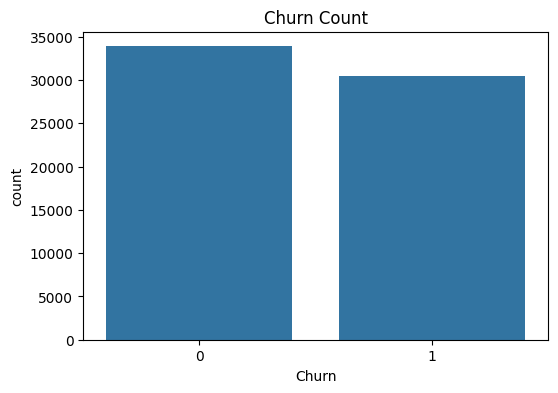

In [10]:
# Catagorial Features 
for col in ['Gender', 'Subscription Type', 'Contract Length', 'Churn']:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f'{col} Count')
    plt.show()

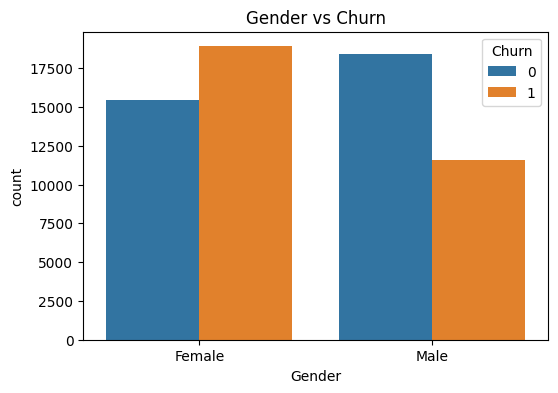

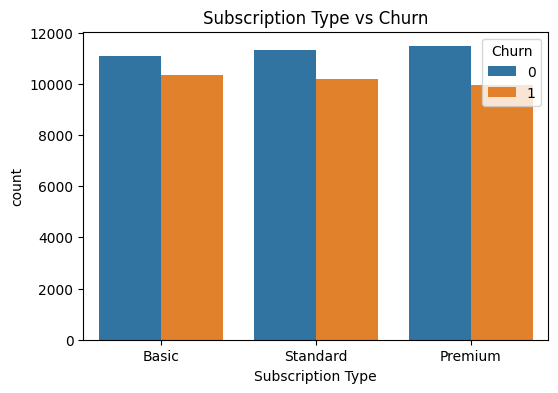

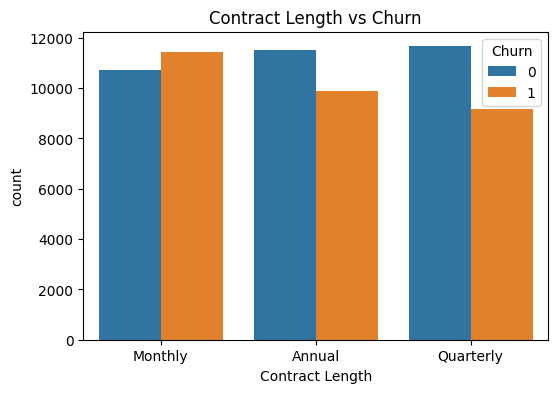

In [11]:
# Bivariate Analysis 
# catagorial vs Churn 
for col in ['Gender', 'Subscription Type', 'Contract Length']:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(f'{col} vs Churn')
    plt.show()

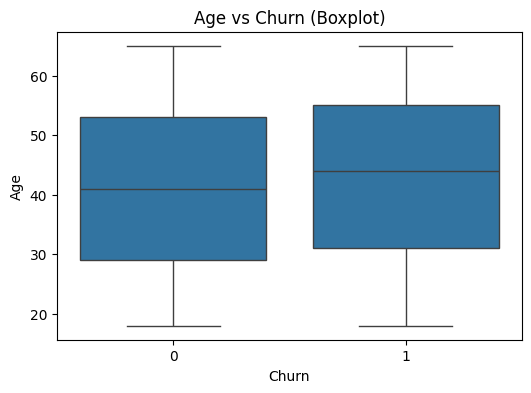

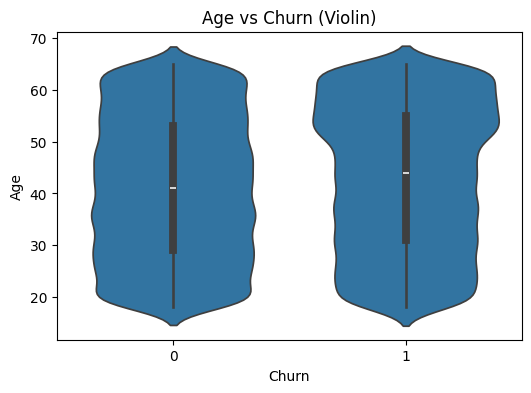

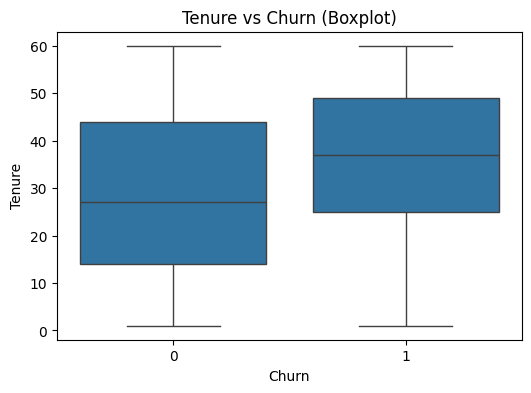

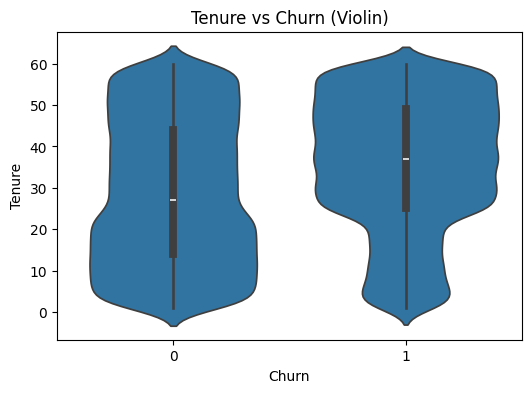

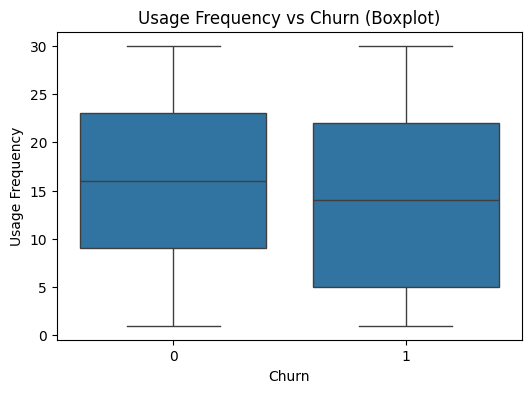

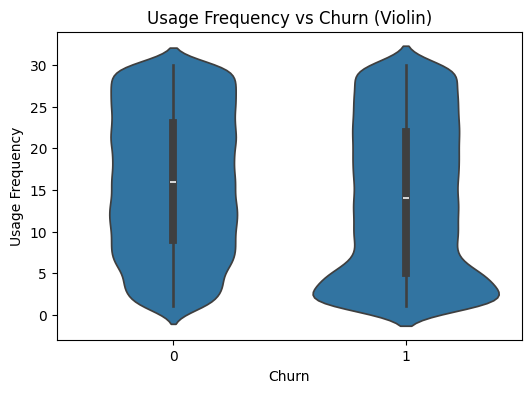

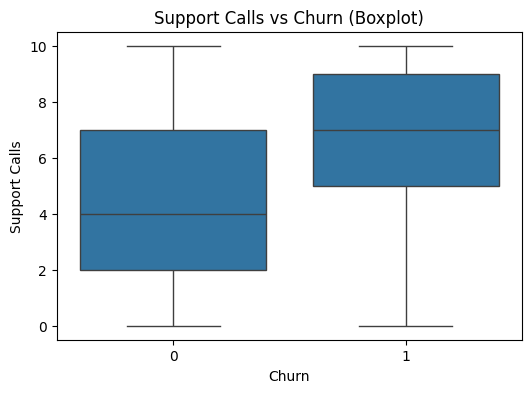

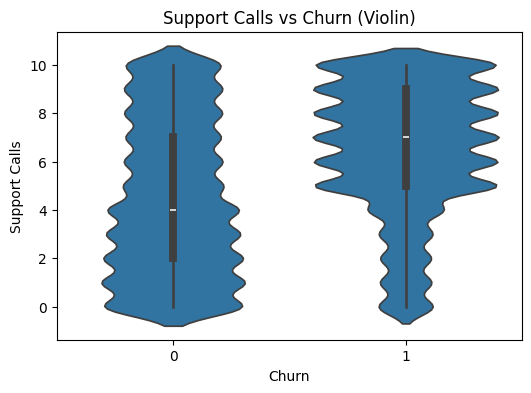

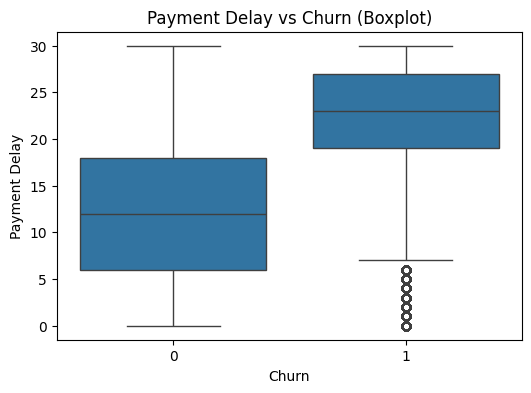

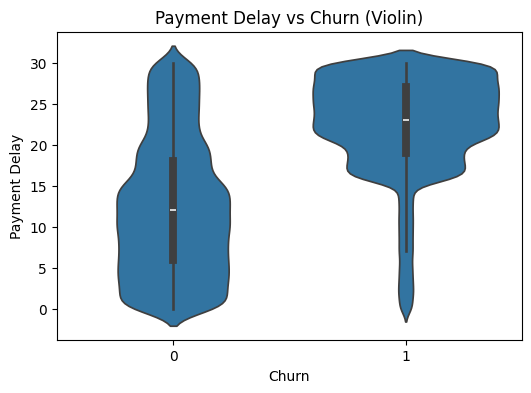

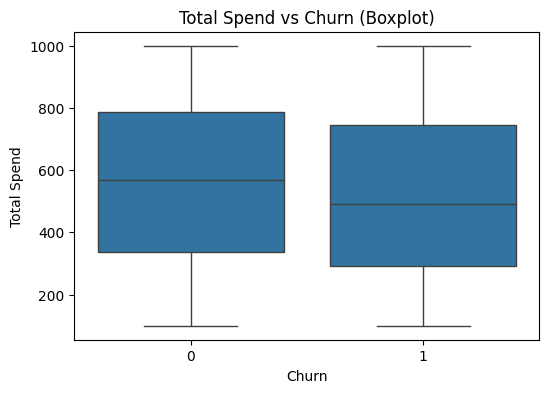

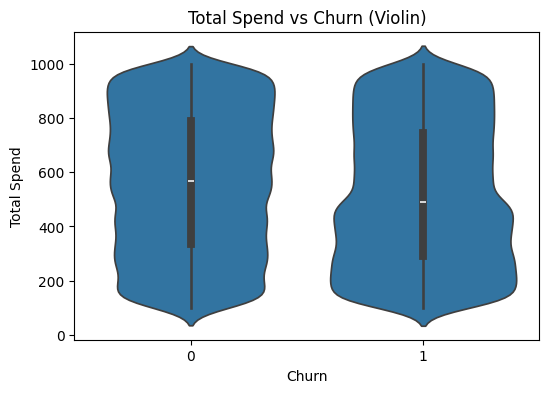

In [12]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(f'{col} vs Churn (Boxplot)')
    plt.show()

    plt.figure(figsize=(6,4))
    sns.violinplot(x='Churn', y=col, data=df)
    plt.title(f'{col} vs Churn (Violin)')
    plt.show()

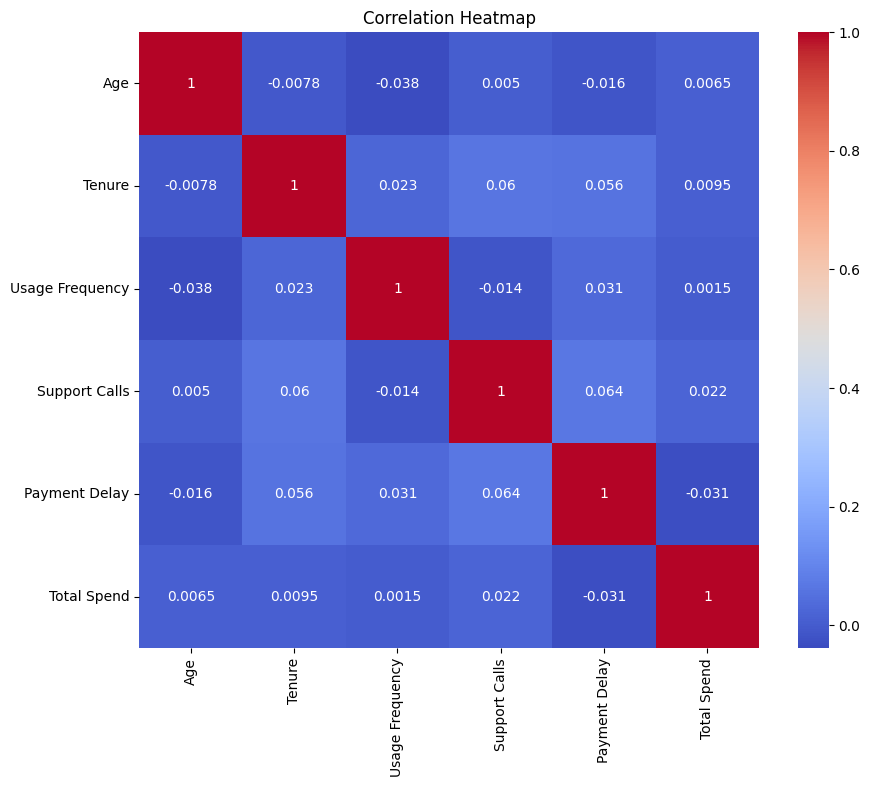

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [13]:
# Preprocessing – Encoding, Splitting, Scaling
# Encode Categorical Data
le = LabelEncoder()
for col in ['Gender', 'Subscription Type', 'Contract Length']:
    df[col] = le.fit_transform(df[col])

df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,0,25,14,4,27,0,1,598,9,1
1,2,41,0,28,28,7,13,2,1,584,20,0
2,3,47,1,27,10,2,29,1,0,757,21,0
3,4,35,1,9,12,5,17,1,2,232,18,0
4,5,53,0,58,24,9,2,2,0,533,18,0


In [14]:
# Features & Target
X = df.drop(['CustomerID', 'Churn', 'Last Interaction', 'Total Spend'], axis=1)
y = df['Churn']

In [15]:
# train test and split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (51499, 8)
X_test shape: (12875, 8)
y_train shape: (51499,)
y_test shape: (12875,)
X_train shape: (51499, 8)
X_test shape: (12875, 8)
y_train shape: (51499,)
y_test shape: (12875,)


In [16]:
# Scaling
num_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])
# Check first 5 rows after scaling
print(X_train[num_cols].head())

            Age    Tenure  Usage Frequency  Support Calls  Payment Delay
17402  1.002290  0.467698        -0.347864      -1.413220      -1.935572
20461 -0.289317 -0.117619        -1.254923      -0.448905      -0.918315
63787 -1.437413 -0.117619         0.672577       0.836848       0.211971
12218  0.212974 -1.171191         1.239489       1.479724      -0.805286
6831   1.217558  0.292103        -0.234481       0.193971       0.551057


In [17]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)  # max_iter increased to ensure convergence
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8257087378640777
Confusion Matrix:
 [[5595 1181]
 [1063 5036]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.83      0.83      6776
           1       0.81      0.83      0.82      6099

    accuracy                           0.83     12875
   macro avg       0.83      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875



In [18]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9585242718446602
Confusion Matrix:
 [[6522  254]
 [ 280 5819]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96      6776
           1       0.96      0.95      0.96      6099

    accuracy                           0.96     12875
   macro avg       0.96      0.96      0.96     12875
weighted avg       0.96      0.96      0.96     12875



In [19]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.9669902912621359
Confusion Matrix:
 [[6451  325]
 [ 100 5999]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.97      6776
           1       0.95      0.98      0.97      6099

    accuracy                           0.97     12875
   macro avg       0.97      0.97      0.97     12875
weighted avg       0.97      0.97      0.97     12875



In [20]:
#XG BOOST
xgb = XGBClassifier(eval_metric='logloss', random_state=42)


xgb.fit(X_train, y_train)


y_pred_xgb = xgb.predict(X_test)


print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9641941747572815
Confusion Matrix:
 [[6469  307]
 [ 154 5945]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.97      6776
           1       0.95      0.97      0.96      6099

    accuracy                           0.96     12875
   macro avg       0.96      0.96      0.96     12875
weighted avg       0.96      0.96      0.96     12875



(0.8, 1.0)

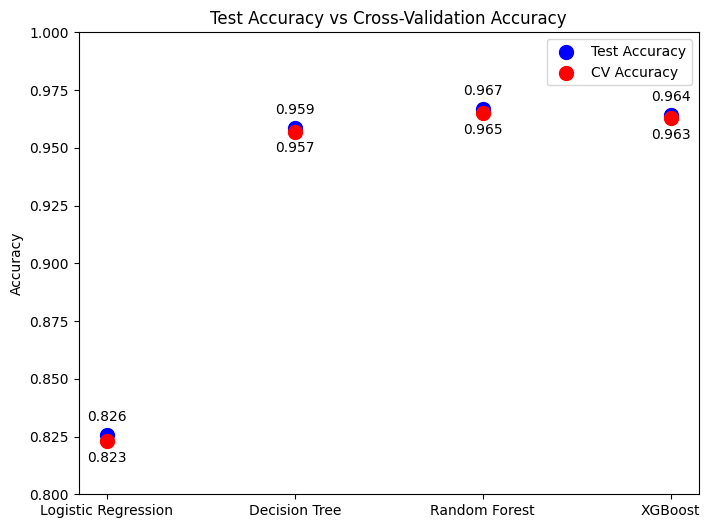

In [21]:
# scatter plot comparing the test accuracy of your models vs the cross-validation
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']

# Previous test accuracies 
test_accuracies = [0.8257, 0.9585, 0.9669, 0.9641]

# Cross-validation accuracies (5-fold CV)
cv_accuracies = [0.823, 0.957, 0.965, 0.963]  # example values, replace with your cv_scores.mean()

# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(models, test_accuracies, color='blue', label='Test Accuracy', s=100)
plt.scatter(models, cv_accuracies, color='red', label='CV Accuracy', s=100)

# Annotate points
for i, txt in enumerate(test_accuracies):
    plt.annotate(f"{txt:.3f}", (models[i], test_accuracies[i]), textcoords="offset points", xytext=(0,10), ha='center')
for i, txt in enumerate(cv_accuracies):
    plt.annotate(f"{txt:.3f}", (models[i], cv_accuracies[i]), textcoords="offset points", xytext=(0,-15), ha='center')

plt.ylabel('Accuracy')
plt.title('Test Accuracy vs Cross-Validation Accuracy')
plt.legend()
plt.ylim(0.8,1.0)

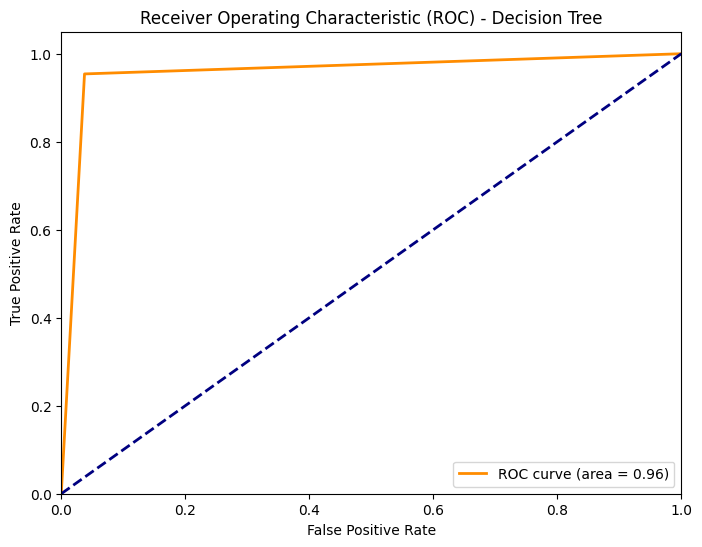

In [22]:
y_prob_dt = dt.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(8,6))
plt.plot(fpr_dt, tpr_dt, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Decision Tree')
plt.legend(loc='lower right')
plt.show()

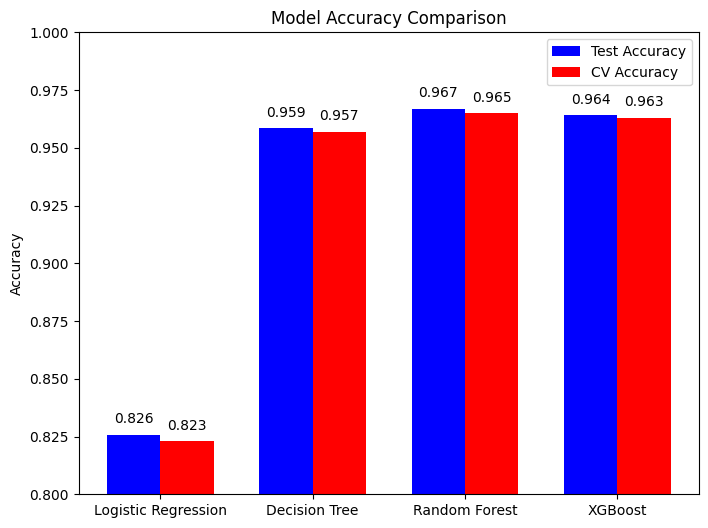

In [23]:


models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']

test_accuracies = [0.8257, 0.9585, 0.9669, 0.9641]
cv_accuracies = [0.823, 0.957, 0.965, 0.963]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,6))

plt.bar(x - width/2, test_accuracies, width, label='Test Accuracy', color='blue')
plt.bar(x + width/2, cv_accuracies, width, label='CV Accuracy', color='red')

plt.xticks(x, models)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0.8, 1.0)
plt.legend()

# Add values on bars
for i in range(len(models)):
    plt.text(i - width/2, test_accuracies[i]+0.005, f"{test_accuracies[i]:.3f}", ha='center')
    plt.text(i + width/2, cv_accuracies[i]+0.005, f"{cv_accuracies[i]:.3f}", ha='center')

plt.show()

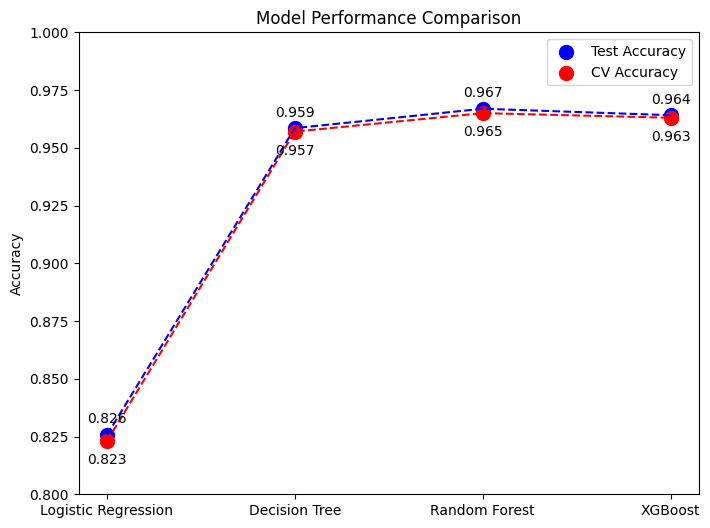

In [24]:
# line plus scatter plot 


models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']

test_accuracies = [0.8257, 0.9585, 0.9669, 0.9641]
cv_accuracies = [0.823, 0.957, 0.965, 0.963]

plt.figure(figsize=(8,6))

# Scatter points
plt.scatter(models, test_accuracies, color='blue', s=100, label='Test Accuracy')
plt.scatter(models, cv_accuracies, color='red', s=100, label='CV Accuracy')

# Line connecting points
plt.plot(models, test_accuracies, color='blue', linestyle='--')
plt.plot(models, cv_accuracies, color='red', linestyle='--')

# Labels
plt.title('Model Performance Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)
plt.legend()

# Annotate values
for i in range(len(models)):
    plt.text(models[i], test_accuracies[i]+0.005, f"{test_accuracies[i]:.3f}", ha='center')
    plt.text(models[i], cv_accuracies[i]-0.01, f"{cv_accuracies[i]:.3f}", ha='center')

plt.show()

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Define model
model = RandomForestClassifier(random_state=42)

# Run cross-validation
scores = cross_val_score(model, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [0.96582524 0.96761165 0.9664466  0.96551456 0.96799751]
Mean accuracy: 0.9666791145244951
